In [1]:
!pip install torch torchvision torchaudio numpy matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

  Using cached matplotlib-3.10.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-macos

In [2]:
# Tạo dữ liệu
X, y = make_circles(n_samples=1000, noise=0.03, factor=0.5, random_state=RANDOM_SEED)

# Chuyển đổi sang Torch Tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float).unsqueeze(1)

print(f"Kích thước dữ liệu X: {X.shape}")
print(f"Kích thước nhãn y: {y.shape}")

Kích thước dữ liệu X: torch.Size([1000, 2])
Kích thước nhãn y: torch.Size([1000, 1])


In [3]:
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Lớp ẩn 4 nút nhận vào 2 đặc trưng (x, y)
        self.layer_1 = nn.Linear(in_features=2, out_features=4)
        # Lớp đầu ra 1 nút
        self.layer_2 = nn.Linear(in_features=4, out_features=1)
        # Hàm kích hoạt phi tuyến
        self.relu = nn.ReLU()

    def forward(self, x):
        # x -> layer 1 -> relu -> layer 2 -> output (logits)
        return self.layer_2(self.relu(self.layer_1(x)))

# Khởi tạo mô hình mẫu
model_example = CircleModel()

Đang huấn luyện với Learning Rate: 0.001...
Đang huấn luyện với Learning Rate: 0.01...
Đang huấn luyện với Learning Rate: 0.1...


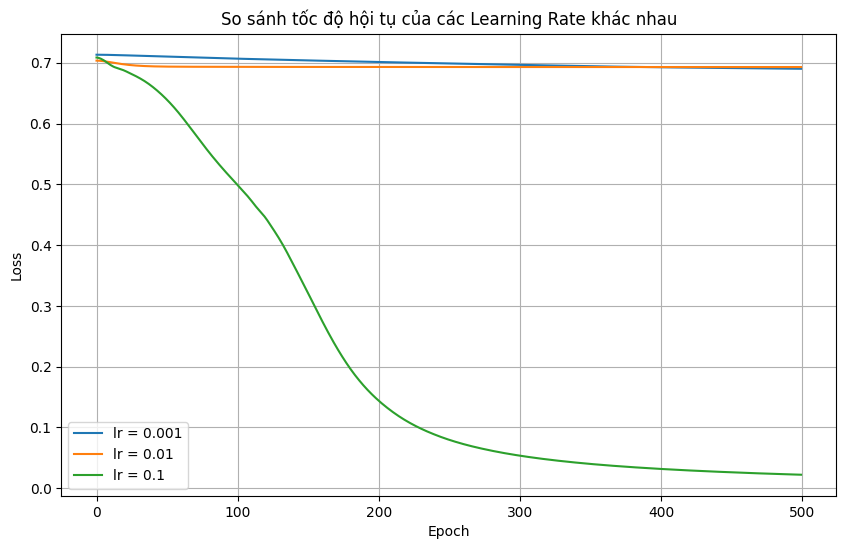

In [4]:
learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    print(f"Đang huấn luyện với Learning Rate: {lr}...")
    model = CircleModel()
    # Yêu cầu Phần 2: Dùng SGD với Momentum và BCEWithLogitsLoss
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    loss_list = []
    for epoch in range(500):
        model.train()
        # Forward pass
        y_logits = model(X)
        loss = criterion(y_logits, y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_list.append(loss.item())
    
    results[lr] = loss_list

# Vẽ biểu đồ so sánh Learning Rate
plt.figure(figsize=(10, 6))
for lr, losses in results.items():
    plt.plot(losses, label=f'lr = {lr}')

plt.title('So sánh tốc độ hội tụ của các Learning Rate khác nhau')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('comparison_lr.png')
plt.show()

- BCEWithLogitsLoss: Thay vì dùng Sigmoid ở lớp cuối rồi mới tính BCELoss, việc dùng gộp hàm này giúp tính toán ổn định hơn. Nó sử dụng kỹ thuật log-sum-exp để tránh hiện tượng số quá nhỏ hoặc quá lớn gây lỗi tính toán.

- SGD + Momentum (0.9): Việc sử dụng SGD thay cho Adam yêu cầu sự tinh chỉnh kỹ hơn về lr. Tuy nhiên, với momentum = 0.9, thuật toán đã tận dụng được "quán tính" từ các lần cập nhật trước, giúp vượt qua các vùng phẳng của hàm mất mát và hội tụ về đích nhanh hơn so với SGD thông thường.

Biểu đồ comparison_lr cung cấp cái nhìn rõ nét về tầm quan trọng của việc chọn tốc độ học (Learning Rate):

- Với $lr = 0.1$ (Đường màu xanh lá): Đây là mức cấu hình tốt nhất. Loss giảm rất nhanh ngay từ 50 epoch đầu tiên và tiệm cận về 0 nhanh chóng. Điều này cho thấy bước nhảy của gradient đủ lớn để tiến tới điểm tối ưu nhưng vẫn đủ kiểm soát để không bị vọt quá đà.

- Với $lr = 0.01$ (Đường màu cam): Mô hình vẫn hội tụ và giảm loss ổn định, nhưng tốc độ chậm hơn nhiều so với mức 0.1. Đến epoch 500, giá trị loss vẫn cao hơn so với mức 0.1.

- Với $lr = 0.001$ (Đường màu xanh dương): Đường loss gần như đi ngang hoặc giảm rất ít. Ở mức này, mô hình đang "học quá cẩn thận", các bước cập nhật trọng số quá nhỏ khiến mạng cần hàng ngàn epoch mới có thể đạt được kết quả như mức 0.1.

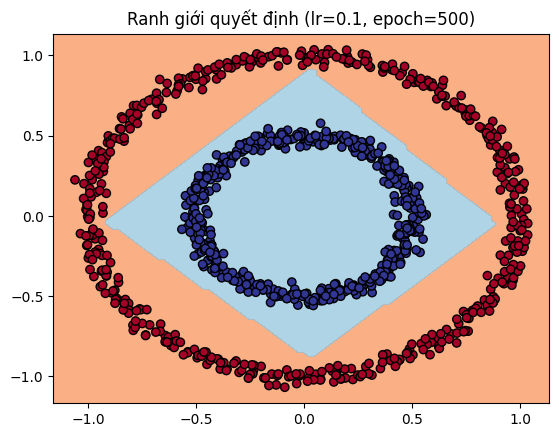

In [ ]:
def plot_boundary(model, X, y, title, filename):
    # Tạo lưới điểm (grid) để dự đoán
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).type(torch.float)

    model.eval()
    with torch.no_grad():
        # Dự đoán: vì model trả về logits nên phải qua sigmoid
        y_preds = torch.sigmoid(model(grid))
        y_preds = (y_preds > 0.5).reshape(xx.shape)

    plt.contourf(xx, yy, y_preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.title(title)
    plt.savefig(filename)
    plt.show()

plot_boundary(model, X, y, "Ranh giới quyết định (lr=0.1, epoch=500)", "final_boundary.png")

Dựa trên biểu đồ final_boundary , ta có các nhận xét sau:

- Khả năng phân loại: Mô hình ANN với lớp ẩn (Hidden Layer) và hàm kích hoạt ReLU đã học được cách phân tách hai tập dữ liệu hình vòng tròn lồng nhau. Đây là bài toán mà các thuật toán tuyến tính đơn giản (như Linear Regression thuần túy) không thể giải quyết được vì chúng chỉ có thể tạo ra các đường thẳng.

- Hình dạng ranh giới: Ranh giới có dạng một hình đa giác khép kín bao quanh cụm điểm màu đỏ ở giữa. Điều này chứng tỏ mạng nơ-ron đã kết hợp các đường thẳng từ các nơ-ron lớp ẩn để tạo thành một bề mặt phân loại phức tạp.

- Độ chính xác trực quan: Các điểm dữ liệu gần như được phân loại hoàn hảo, không có sự chồng lấn đáng kể giữa vùng màu xanh và vùng màu đỏ.